In [ ]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importing the wine dataset
df=pd.read_csv("wine-clustering.csv")

In [ ]:
#to check whether the dataset has been imported correctly
print("Shape of the dataset: ",df.shape)
print("First few entries of the dataset: ")
print(df.head())

Shape of the dataset:  (178, 13)
First few entries of the dataset: 
   Alcohol  Malic_Acid   Ash  Ash_Alkalinity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43            15.6        127           2.80   
1    13.20        1.78  2.14            11.2        100           2.65   
2    13.16        2.36  2.67            18.6        101           2.80   
3    14.37        1.95  2.50            16.8        113           3.85   
4    13.24        2.59  2.87            21.0        118           2.80   

   Flavonoids  Nonflavonoid_Phenols  Proanthocyanidins  Color_Intensity   Hue  \
0        3.06                  0.28               2.29             5.64  1.04   
1        2.76                  0.26               1.28             4.38  1.05   
2        3.24                  0.30               2.81             5.68  1.03   
3        3.49                  0.24               2.18             7.80  0.86   
4        2.69                  0.39               1.82             4.32  1.04   



In [ ]:
#to check the type of variable in the imported dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alkalinity        178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavonoids            178 non-null    float64
 7   Nonflavonoid_Phenols  178 non-null    float64
 8   Proanthocyanidins     178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


Interpretation: All the varaibles are numerical in nature.

In [ ]:
#to check the presence of null values
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alkalinity          0
Magnesium               0
Total_Phenols           0
Flavonoids              0
Nonflavonoid_Phenols    0
Proanthocyanidins       0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Interpretation: The dataset has no null values.

In [ ]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alkalinity,Magnesium,Total_Phenols,Flavonoids,Nonflavonoid_Phenols,Proanthocyanidins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Interpretation: Since the minimum and maximum values of each variables are not far way from each, Standardization is not required.

TO CHECK THE CORRELATION PRESENT IN THE DATASET, WE CONSIDER CERTAIN MEASURES:
1. CORRELATION MATRIX (HEATMAP)
2. BARTLETT'S TEST
3. KMO TEST

1. HEATMAP

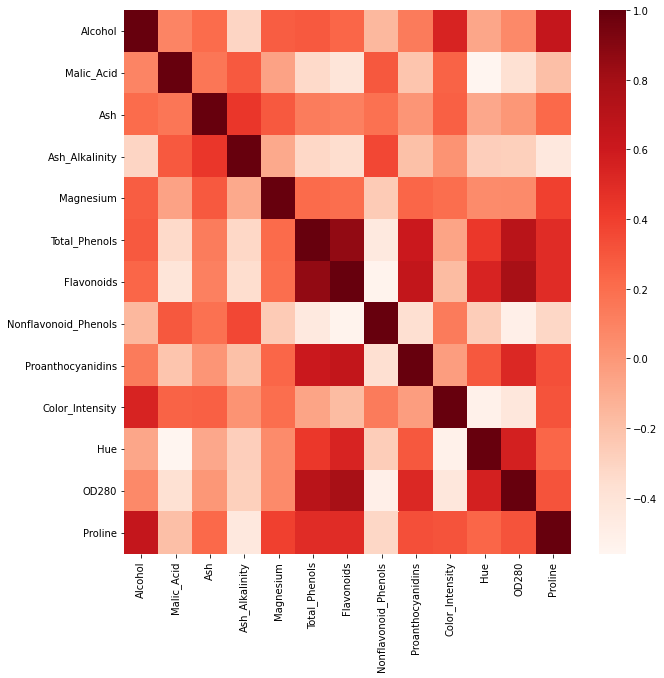

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10] 
corr = df.corr()
sns.heatmap(corr, cmap='Reds')

Interpretation: There are some variables that are strongly correlated to each other, i.e, the dataset is useful for further analysis.

2. BARTLETT'S TEST

In [ ]:
pip install factor_analyzer 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 41 kB 622 kB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 199 kB 13.7 MB/s 
     |████████████████████████████████| 98 kB 7.6 MB/s 
     |████████████████████████████████| 8.8 MB 51.9 MB/s 
     |████████████████████████████████| 468 kB 48.6 MB/s 
  Created wheel for factor-analyzer: filename=factor_analyzer-0.4.1-py2.py3-none-any.whl size=42034 sha256=883a54256bdf998622b43d6356291a9131fc3da925458355f0a2f3fc36b3b72d
  Stored in directory: /root/.cache/pip/wheels/ed/90/48/766e09628cc5bbcf57c2eb063972c1e956a03422dd6d84fde2
Successfully built factor-analyzer


Factor Analysis is used to get the underlying latent variables and also to reduce the dimensions of the dataset.

To proceed with Factor Analysis, we need to check whether the dataset is suitable for performing factor analysis.

In [ ]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
calculate_bartlett_sphericity(df)

(1317.1808094724372, 2.468617032425556e-224)

Bartlett's Test helps the analyst to check if the dataset is fit for Factor Analysis. The Bartlett test statistic is designed to test for equality of variances across groups against the alternative that variances are unequal for at least two groups. It returns the chi-square and p-value of the dataset. If the p-values is less than 0.5, then we reject the null hypothesis, and conclude that the dataset is fit to perform factor analysis. 

Interpretation: Since the resulted p-value is lesser than 0.5, we can conclude that the varibles are strongly correlated and we can proceed with Factor Analysis. 

3. KMO TEST

The Kaiser-Meyer-Olkin (KMO) Test is a measure of how suited your data is for Factor Analysis. The test measures sampling adequacy for each variable in the model and for the complete model. The statistic is a measure of the proportion of variance among variables that might be common variance. The lower the proportion, the more suited your data is to Factor Analysis.

KMO returns values between 0 and 1. A rule of thumb for interpreting the statistic:

KMO values between 0.8 and 1 indicate the sampling is adequate.
KMO values less than 0.6 indicate the sampling is not adequate and that remedial action should be taken. Some authors put this value at 0.5, so use your own judgment for values between 0.5 and 0.6.
KMO Values close to zero means that there are large partial correlations compared to the sum of correlations. In other words, there are widespread correlations which are a large problem for factor analysis.

In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(df)
print(kmo_model)

0.7786821205606519


Interpretation: KMO values closer to 1.0 are consider ideal while values less than 0.5 are unacceptable.

Interpretation: The results from Bartlett's Test and KMO Test were good enough to go ahead with Factor Analysis.

In [ ]:
# instantiate the Factor Analyzer
fa = FactorAnalyzer() 

# Fit the dataframe using Factor Analyzer
fa.fit(df)

FactorAnalyzer(rotation_kwargs={})

In [ ]:
# Identify the eigenvalues
ev, v = fa.get_eigenvalues() #eigenvalues

print("Eigenvalues:", ev)

Eigenvalues: [4.70585025 2.49697373 1.44607197 0.91897392 0.85322818 0.64165703
 0.55102831 0.34849736 0.28887994 0.25090248 0.22578864 0.16877023
 0.10337794]


Interpretation: The above array of eigenvalues shows that we can create three factors.

Scree Plot test: This method is to decide about the number of factors to be retained from the
extracted factors. The test determines which of the extracted factors are actually contributing
variance and does not measure random errors. The number of factors is plotted against the
proportion of variance. It extracts in the order of the extracted factors.

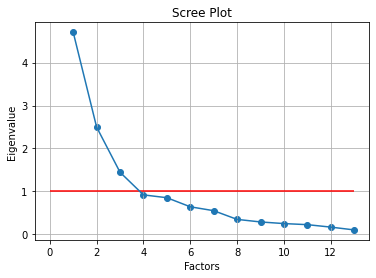

In [ ]:
# Create scree plot using matplotlib
plt.figure(figsize=(6,4))
plt.scatter(range(1,df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.hlines(1, 0, df.shape[1], colors='r')
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()


Interpretation: The factor analysis resulted in three ideal factors.

To check what variables are supposed to be considered in each factor for further analysis, we see the factor loadings and set the cutoff to be 0.6.

In [ ]:
fa = FactorAnalyzer(3, rotation='varimax')
fa.fit(df)
print(fa.loadings_)

[[ 0.03531242  0.79797351 -0.0656662 ]
 [-0.49493716  0.0930058   0.22772833]
 [ 0.02589812  0.31224745  0.72686046]
 [-0.30098009 -0.30577719  0.75213103]
 [ 0.1676417   0.39613711  0.12080209]
 [ 0.7981418   0.33600856  0.03406058]
 [ 0.92081185  0.26288696  0.01631919]
 [-0.5197615  -0.17005419  0.24405746]
 [ 0.59153039  0.22101387  0.01902462]
 [-0.42744518  0.71150604  0.11309432]
 [ 0.67803678 -0.17568441 -0.14442634]
 [ 0.86228104 -0.01119932 -0.03229989]
 [ 0.3755546   0.72721315 -0.09947232]]


In [ ]:
lmatrix = pd.DataFrame(fa.loadings_, index = list(df.columns), columns = ['Factor 1', 'Factor 2', 'Factor 3'])
lmatrix

,Factor 1,Factor 2,Factor 3
Alcohol,0.035312,0.797974,-0.065666
Malic_Acid,-0.494937,0.093006,0.227728
Ash,0.025898,0.312247,0.726860
Ash_Alkalinity,-0.300980,-0.305777,0.752131
Magnesium,0.167642,0.396137,0.120802
Total_Phenols,0.798142,0.336009,0.034061
Flavonoids,0.920812,0.262887,0.016319
Nonflavonoid_Phenols,-0.519761,-0.170054,0.244057
Proanthocyanidins,0.591530,0.221014,0.019025
Color_Intensity,-0.427445,0.711506,0.113094


To check what variables are supposed to be considered in each factor for further analysis, we see the factor loadings and set the cutoff to be 0.6.

In [ ]:
print(pd.DataFrame(fa.get_factor_variance(),index=['Variance','Proportional Var','Cumulative Var'], columns = ['Factor 1', 'Factor 2', 'Factor 3']))

                  Factor 1  Factor 2  Factor 3
Variance          3.997571  2.319182  1.270732
Proportional Var  0.307505  0.178399  0.097749
Cumulative Var    0.307505  0.485904  0.583653


In [ ]:
print(pd.DataFrame(fa.get_communalities(),index=df.columns,columns=['Communalities']))

                      Communalities
Alcohol                    0.642321
Malic_Acid                 0.305473
Ash                        0.626495
Ash_Alkalinity             0.749790
Magnesium                  0.199621
Total_Phenols              0.751092
Flavonoids                 0.917270
Nonflavonoid_Phenols       0.358634
Proanthocyanidins          0.399117
Color_Intensity            0.701741
Hue                        0.511458
OD280                      0.744697
Proline                    0.679775


In [ ]:
lmatrix.sort_values('Factor 1', ascending=False)

,Factor 1,Factor 2,Factor 3
Flavonoids,0.920812,0.262887,0.016319
OD280,0.862281,-0.011199,-0.032300
Total_Phenols,0.798142,0.336009,0.034061
Hue,0.678037,-0.175684,-0.144426
Proanthocyanidins,0.591530,0.221014,0.019025
Proline,0.375555,0.727213,-0.099472
Magnesium,0.167642,0.396137,0.120802
Alcohol,0.035312,0.797974,-0.065666
Ash,0.025898,0.312247,0.726860
Ash_Alkalinity,-0.300980,-0.305777,0.752131


Factor 1: Flavanoids, Total_Phenols, OD280, Proanthocyanidins, Hue

In [ ]:
lmatrix.sort_values('Factor 2', ascending=False)

,Factor 1,Factor 2,Factor 3
Alcohol,0.035312,0.797974,-0.065666
Proline,0.375555,0.727213,-0.099472
Color_Intensity,-0.427445,0.711506,0.113094
Magnesium,0.167642,0.396137,0.120802
Total_Phenols,0.798142,0.336009,0.034061
Ash,0.025898,0.312247,0.726860
Flavonoids,0.920812,0.262887,0.016319
Proanthocyanidins,0.591530,0.221014,0.019025
Malic_Acid,-0.494937,0.093006,0.227728
OD280,0.862281,-0.011199,-0.032300


Factor 2: Alcohol, Proline and Color Intensity

In [ ]:
lmatrix.sort_values('Factor 3', ascending=False)

,Factor 1,Factor 2,Factor 3
Ash_Alkalinity,-0.300980,-0.305777,0.752131
Ash,0.025898,0.312247,0.726860
Nonflavonoid_Phenols,-0.519761,-0.170054,0.244057
Malic_Acid,-0.494937,0.093006,0.227728
Magnesium,0.167642,0.396137,0.120802
Color_Intensity,-0.427445,0.711506,0.113094
Total_Phenols,0.798142,0.336009,0.034061
Proanthocyanidins,0.591530,0.221014,0.019025
Flavonoids,0.920812,0.262887,0.016319
OD280,0.862281,-0.011199,-0.032300


Factor 3: Ash and Ash Alkalinity

In [ ]:
dfn=df[["Flavonoids","OD280", "Total_Phenols","Hue","Proanthocyanidins","Alcohol","Proline","Color_Intensity","Ash","Ash_Alkalinity"]]
dfn.head()

,Flavonoids,OD280,Total_Phenols,Hue,Proanthocyanidins,Alcohol,Proline,Color_Intensity,Ash,Ash_Alkalinity
0,3.06,3.92,2.80,1.04,2.29,14.23,1065,5.64,2.43,15.6
1,2.76,3.40,2.65,1.05,1.28,13.20,1050,4.38,2.14,11.2
2,3.24,3.17,2.80,1.03,2.81,13.16,1185,5.68,2.67,18.6
3,3.49,3.45,3.85,0.86,2.18,14.37,1480,7.80,2.50,16.8
4,2.69,2.93,2.80,1.04,1.82,13.24,735,4.32,2.87,21.0


To check the correlation between the varaibles of factor 1, heatmap was used.

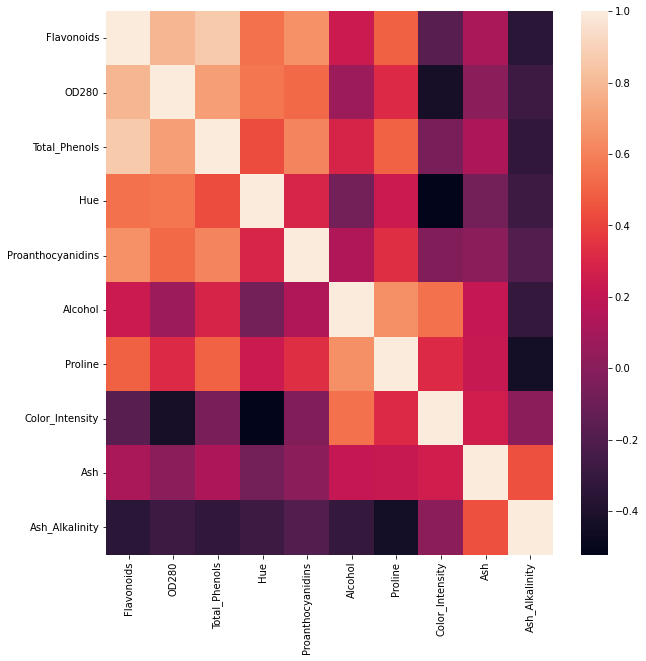

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10] 
corr = dfn.corr()
sns.heatmap(corr)

Interpretation: The heatmap shows that there exists some strong correlations between certain variables.

Clustering was performed on the the reduced dataset to derive certain insights.

K-Means

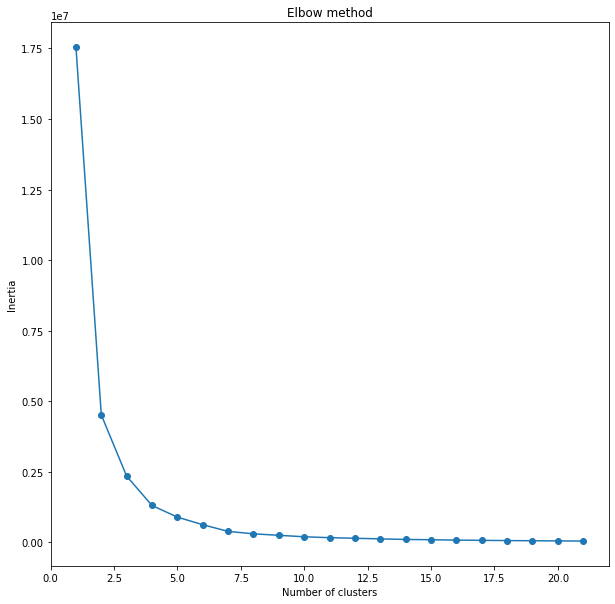

In [ ]:
# Using the elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1,22):
  kmeans=KMeans(n_clusters = i,init="k-means++",random_state = 0)
  kmeans.fit(dfn)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,22), wcss, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



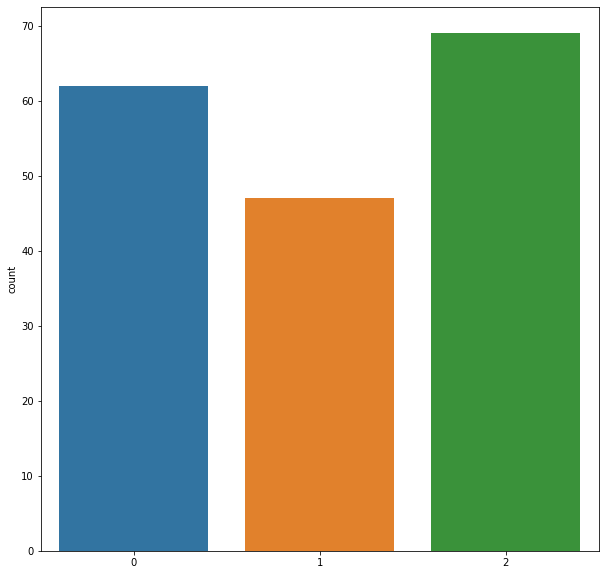

In [ ]:
kmeans=KMeans(n_clusters=3)
n3clusters=kmeans.fit_predict(dfn)
dfn["n3clusters"]=n3clusters
sns.countplot(n3clusters)

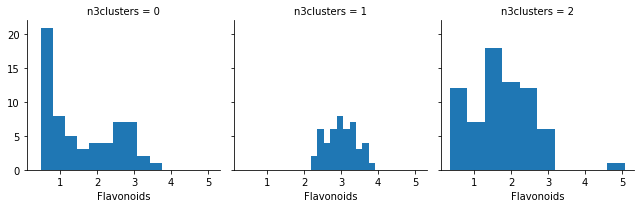

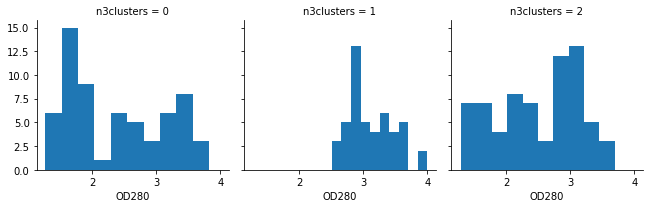

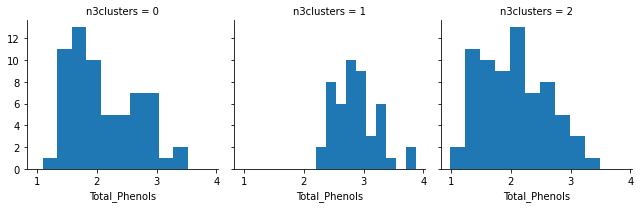

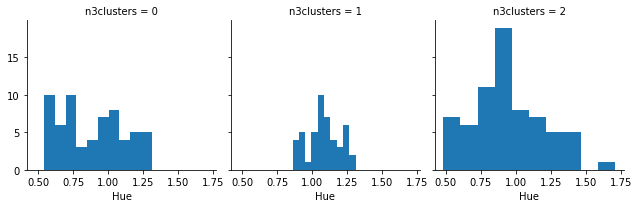

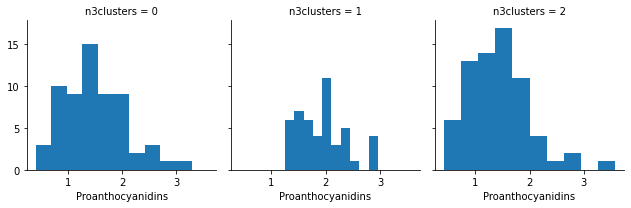

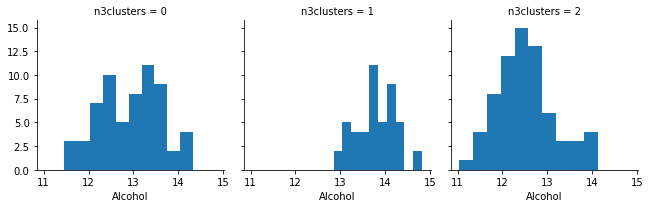

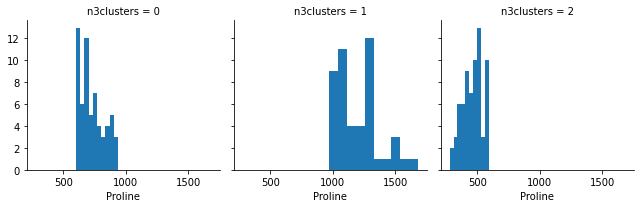

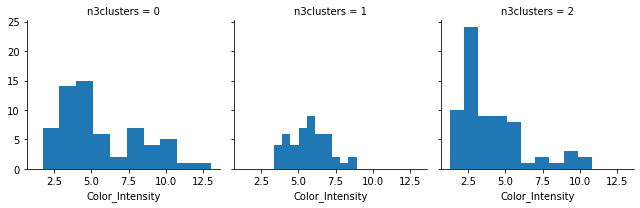

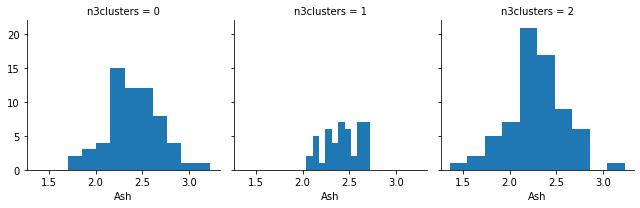

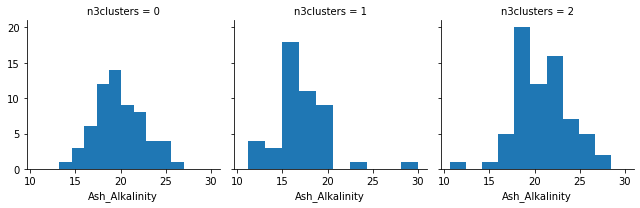

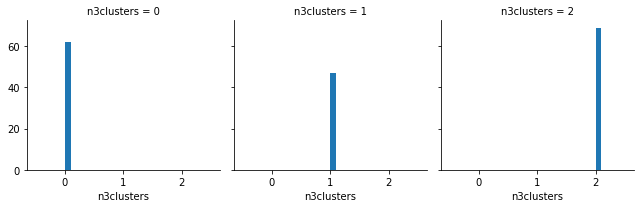

In [ ]:
for c in dfn:
    grid=sns.FacetGrid(dfn, col='n3clusters')
    grid.map(plt.hist,c)

In [ ]:
dfn.drop(['n3clusters'], axis=1)

,Flavonoids,OD280,Total_Phenols,Hue,Proanthocyanidins,Alcohol,Proline,Color_Intensity,Ash,Ash_Alkalinity
0,3.06,3.92,2.80,1.04,2.29,14.23,1065,5.64,2.43,15.6
1,2.76,3.40,2.65,1.05,1.28,13.20,1050,4.38,2.14,11.2
2,3.24,3.17,2.80,1.03,2.81,13.16,1185,5.68,2.67,18.6
3,3.49,3.45,3.85,0.86,2.18,14.37,1480,7.80,2.50,16.8
4,2.69,2.93,2.80,1.04,1.82,13.24,735,4.32,2.87,21.0
...,...,...,...,...,...,...,...,...,...,...
173,0.61,1.74,1.68,0.64,1.06,13.71,740,7.70,2.45,20.5
174,0.75,1.56,1.80,0.70,1.41,13.40,750,7.30,2.48,23.0
175,0.69,1.56,1.59,0.59,1.35,13.27,835,10.20,2.26,20.0
176,0.68,1.62,1.65,0.60,1.46,13.17,840,9.30,2.37,20.0


Visualisation 

In [ ]:
from sklearn.manifold import TSNE #T-Distributed Stochastic Neighbor Embedding

In [ ]:
dfn.drop(['n3clusters'],axis=1)
x = dfn
x.columns = dfn.columns
#Set our perplexity
perplexity = 50


#T-SNE with one dimension
tsne_1d = TSNE(n_components=1, perplexity=perplexity)

#T-SNE with two dimensions
tsne_2d = TSNE(n_components=2, perplexity=perplexity)

#T-SNE with three dimensions
tsne_3d = TSNE(n_components=3, perplexity=perplexity)

TCs_1d = pd.DataFrame(tsne_1d.fit_transform(x))

#This DataFrame contains two dimensions, built by T-SNE
TCs_2d = pd.DataFrame(tsne_2d.fit_transform(x))

#And this DataFrame contains three dimensions, built by T-SNE
TCs_3d = pd.DataFrame(tsne_3d.fit_transform(x))



TCs_1d.columns = ["TC1_1d"]
TCs_2d.columns = ["TC1_2d","TC2_2d"]
TCs_3d.columns = ["TC1_3d","TC2_3d","TC3_3d"]

x = pd.concat([x,TCs_1d,TCs_2d,TCs_3d], axis=1, join='inner')

x["dummy"] = 0

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.



In [ ]:
dfn['n3clusters']=n3clusters

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
cluster0 = x[x["n3clusters"] == 0]
cluster1 = x[x["n3clusters"] == 1]
cluster2 = x[x["n3clusters"] == 2]

In [ ]:
#plotly imports
import plotly as py
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [ ]:
#Instructions for building the 1-D plot

#trace1 is for 'Cluster 0'
trace1 = go.Scatter(
                    x = cluster0["TC1_1d"],
                    y = cluster0["dummy"],
                    mode = "markers",
                    name = "Cluster 0",
                    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
                    text = None)

#trace2 is for 'Cluster 1'
trace2 = go.Scatter(
                    x = cluster1["TC1_1d"],
                    y = cluster1["dummy"],
                    mode = "markers",
                    name = "Cluster 1",
                    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
                    text = None)

#trace3 is for 'Cluster 2'
trace3 = go.Scatter(
                    x = cluster2["TC1_1d"],
                    y = cluster2["dummy"],
                    mode = "markers",
                    name = "Cluster 2",
                    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
                    text = None)

data = [trace1, trace2, trace3]

title = "Visualizing Clusters in One Dimension Using T-SNE (perplexity=" + str(perplexity) + ")"

layout = dict(title = title,
              xaxis= dict(title= 'TC1',ticklen= 5,zeroline= False),
              yaxis= dict(title= '',ticklen= 5,zeroline= False)
             )

fig = dict(data = data, layout = layout)

iplot(fig)

In [ ]:
#Instructions for building the 2-D plot

#trace1 is for 'Cluster 0
trace1 = go.Scatter(
                    x = cluster0["TC1_2d"],
                    y = cluster0["TC2_2d"],
                    mode = "markers",
                    name = "Cluster 0",
                    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
                    text = None)

#trace2 is for 'Cluster 1'
trace2 = go.Scatter(
                    x = cluster1["TC1_2d"],
                    y = cluster1["TC2_2d"],
                    mode = "markers",
                    name = "Cluster 1",
                    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
                    text = None)

#trace3 is for 'Cluster 2'
trace3 = go.Scatter(
                    x = cluster2["TC1_2d"],
                    y = cluster2["TC2_2d"],
                    mode = "markers",
                    name = "Cluster 2",
                    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
                    text = None)

data = [trace1, trace2, trace3]

title = "Visualizing Clusters in Two Dimensions Using T-SNE (perplexity=" + str(perplexity) + ")"
layout = dict(title = title,
              xaxis= dict(title= 'TC1',ticklen= 5,zeroline= False),
              yaxis= dict(title= 'TC2',ticklen= 5,zeroline= False)
             )

fig = dict(data = data, layout = layout)

iplot(fig)

In [ ]:
#Instructions for building the 3-D plot

#trace1 is for 'Cluster 0'
trace1 = go.Scatter3d(
                    x = cluster0["TC1_3d"],
                    y = cluster0["TC2_3d"],
                    z = cluster0["TC3_3d"],
                    mode = "markers",
                    name = "Cluster 0",
                    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
                    text = None)

#trace2 is for 'Cluster 1'
trace2 = go.Scatter3d(
                    x = cluster1["TC1_3d"],
                    y = cluster1["TC2_3d"],
                    z = cluster1["TC3_3d"],
                    mode = "markers",
                    name = "Cluster 1",
                    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
                    text = None)

#trace3 is for 'Cluster 2'
trace3 = go.Scatter3d(
                    x = cluster2["TC1_3d"],
                    y = cluster2["TC2_3d"],
                    z = cluster2["TC3_3d"],
                    mode = "markers",
                    name = "Cluster 2",
                    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
                    text = None)

data = [trace1, trace2, trace3]

title = "Visualizing Clusters in Three Dimensions Using T-SNE (perplexity=" + str(perplexity) + ")"

layout = dict(title = title,
              xaxis= dict(title= 'TC1',ticklen= 5,zeroline= False),
              yaxis= dict(title= 'TC2',ticklen= 5,zeroline= False)
             )

fig = dict(data = data, layout = layout)

iplot(fig)